In [2]:
import pandas as pd
import numpy as np
from sklearn import linear_model #Provides us linear regression model
import matplotlib.pyplot as plt #Used for ploting the graphs

In [4]:
df = pd.read_csv("/content/home_prices.csv")
df

,area,price
0,1360,154206
1,4272,677854
2,3592,576697
3,966,118319
4,4926,739536
...,...,...
95,1528,244933
96,1002,189345
97,4993,733648
98,1370,236123


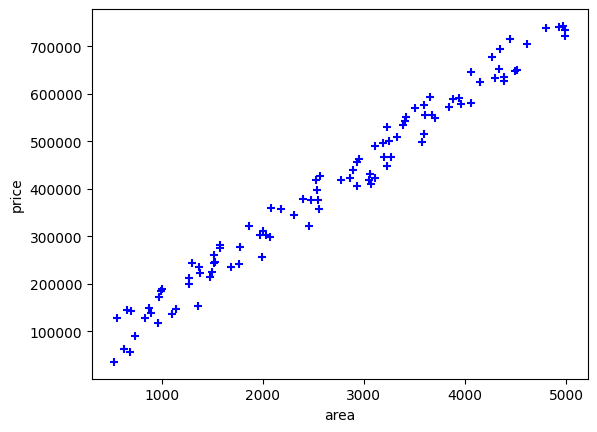

In [5]:
plt.xlabel('area') #House area X axis
plt.ylabel('price') #House price Y axis
plt.scatter(df.area,df.price,color='BLUE',marker='+')

In [6]:
new_df = df.drop('price', axis = 'columns')
new_df

,area
0,1360
1,4272
2,3592
3,966
4,4926
...,...
95,1528
96,1002
97,4993
98,1370


In [7]:
price = df.price
price

,price
0,154206
1,677854
2,576697
3,118319
4,739536
...,...
95,244933
96,189345
97,733648
98,236123


In [8]:
reg = linear_model.LinearRegression()
reg.fit(new_df,price)

LinearRegression()

In [13]:
reg.predict([[5000]]) #Price prediction of property with 5000 area

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([749942.56524642])

In [10]:
reg.coef_ #value of M in y = m x + c (Price per square foot)

array([148.27816676])

In [11]:
reg.intercept_ #value of C in y = m x + c (Base price of property)

np.float64(8551.731434376794)

In [14]:
148.27816676 * 5000 + 8551.731434376794 # y = m x + c

749942.5652343768

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [25]:
x = df[["area"]]
y = df[["price"]]
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size = 0.2) #80% would be for training and 20% for testing

In [26]:
reg.fit(train_x,train_y)

LinearRegression()

In [29]:
y_pred = reg.predict(test_x)

In [30]:
print("coefficient (slope):", reg.coef_[0])
print("intercept:", reg.intercept_)
print("MSE:", mean_squared_error(test_y, y_pred)) # Lower = Better
print("R2 score:", r2_score(test_y, y_pred))


coefficient (slope): [147.46756225]
intercept: [8875.99505943]
MSE: 781908861.3294404
R2 score: 0.978627712859937


1.0 --> Perfect model

0.9+ --> Excellent model

0.5 --> Average model, Improvement needed

0 or less than 2.5 --> Bad model